# Notebook 02 -- Weather Processing and Renewable Generation Prediction

**Purpose:** Process the regional weather data collected in Notebook 01, compute capacity-weighted national averages, and train XGBoost models to predict wind and solar generation from weather features.

**Pipeline overview:**
1. Reload REPD and recompute regional capacity weights (for weighted averaging)
2. Load per-region wind and solar weather CSVs from `data/processed/regions/`
3. Quality-control the wind data (flag suspicious readings, cap extreme values)
4. Compute **capacity-weighted national averages** for wind and solar weather variables
5. Merge into a single weather feature file
6. Train **XGBoost regressors** to predict actual wind/solar generation from weather features
7. Compare model performance when trained on actual vs. forecast weather (degradation analysis)

**Inputs:**
- `data/raw/renew_repd_sites_desnz.csv` -- REPD database
- `data/processed/regions/*.csv` -- Per-region weather files from Notebook 01
- `data/raw/renew_gen_forecast_da_hourly_bmrs.csv` -- BMRS actual generation (training targets)

**Outputs:**
- `data/processed/wind_weighted_final.csv` -- Capacity-weighted wind weather
- `data/processed/solar_weighted_final.csv` -- Capacity-weighted solar weather
- `data/processed/weather_final.csv` -- Merged weather features for the price model

In [1]:
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
import time
from pyproj import Transformer
import warnings
warnings.filterwarnings('ignore')

print("Imports complete")

Imports complete


## 1. Setup and REPD Regional Weights

Import libraries, reload the REPD database, and recompute capacity-weighted centroids for each UK region. These weights are needed to combine per-region weather data into a single national average that reflects where generation capacity is actually installed.

In [2]:
# Time period
start_date = '2021-01-01'
end_date = '2025-10-31'

# Technology filters
WIND_ONSHORE = 'Wind Onshore'
WIND_OFFSHORE = 'Wind Offshore'
SOLAR = 'Solar Photovoltaics'

# Minimum capacity threshold (MW) - filter out tiny installations
MIN_CAPACITY_MW = 1.0

print(f"Configuration set: {start_date} to {end_date}")

Configuration set: 2021-01-01 to 2025-10-31


In [3]:
#Load REPD CSV
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPD_PATH = '../data/raw/renew_repd_sites_desnz.csv'

# Check if the file exists before trying to read it
if not os.path.exists(REPD_PATH):
    print(f"File not found: {REPD_PATH}")
else:
    repd_raw = pd.read_csv(REPD_PATH, encoding='latin-1')
    print(f"Loaded {len(repd_raw)} records from REPD")
    print(repd_raw.head())

Loaded 13524 records from REPD
   Old Ref ID    Ref ID Record Last Updated (dd/mm/yyyy)  \
0           1  10726459                       07/07/2009   
1           2       NaN                       20/11/2017   
2           3  12019680                       20/12/2019   
3           4  11877116                       18/12/2003   
4           5       NaN                       29/09/2005   

                       Operator (or Applicant)  \
0                                   RWE npower   
1  Orsted (formerly Dong Energy) / Peel Energy   
2           Scottish and Southern Energy (SSE)   
3                       Energy Power Resources   
4                                      Agrigen   

                        Site Name      Technology Type Storage Type  \
0  Aberthaw Power Station Biomass  Biomass (co-firing)          NaN   
1           Hunterston - cofiring  Biomass (co-firing)          NaN   
2   Ferrybridge Multifuel 2 (FM2)     EfW Incineration          NaN   
3  Thetford Biomass Pow

In [4]:
#Filter and cleaning the REPD csv

def clean_repd(df):
    """Filter REPD for operational wind and solar projects"""

    # Check actual column names
    print("Checking column names...")
    print(df.columns.tolist())

    keep_cols = [
        'Site Name', 'Region', 'Technology Type', 'Development Status',
        'Installed Capacity (MWelec)', 'X-coordinate', 'Y-coordinate'
    ]
    print(keep_cols)

    # Filter for operational projects
    df_operational = df[df['Development Status'] == 'Operational'].copy()
    print(f"Operational projects: {len(df_operational)}")

    # Filter for wind and solar
    tech_filter = df_operational['Technology Type'].isin([WIND_ONSHORE, WIND_OFFSHORE, SOLAR])
    df_filtered = df_operational[tech_filter].copy()
    print(f"Wind/Solar operational: {len(df_filtered)}")

    # Convert 'Installed Capacity (MWelec)' to numeric, coercing errors, then drop NaNs
    df_filtered['Installed Capacity (MWelec)'] = pd.to_numeric(df_filtered['Installed Capacity (MWelec)'], errors='coerce')
    df_filtered = df_filtered.dropna(subset=['Installed Capacity (MWelec)']).copy()

    # Filter minimum capacity
    df_filtered = df_filtered[df_filtered['Installed Capacity (MWelec)'] >= MIN_CAPACITY_MW]
    print(f"After {MIN_CAPACITY_MW}MW threshold: {len(df_filtered)}")

    # Remove missing coordinates
    df_filtered = df_filtered.dropna(subset=['X-coordinate', 'Y-coordinate'])
    print(f"With valid coordinates: {len(df_filtered)}")

    df_filtered = df_filtered[keep_cols]

    # Summary by technology
    print("\n" + "="*50)
    print("CAPACITY SUMMARY BY TECHNOLOGY")
    print("="*50)
    summary = df_filtered.groupby('Technology Type')['Installed Capacity (MWelec)'].agg(['count', 'sum'])
    summary.columns = ['Projects', 'Total MW']
    print(summary)
    print("="*50)

    return df_filtered

repd_clean = clean_repd(repd_raw)

Checking column names...
['Old Ref ID', 'Ref ID', 'Record Last Updated (dd/mm/yyyy)', 'Operator (or Applicant)', 'Site Name', 'Technology Type', 'Storage Type', 'Storage Co-location REPD Ref ID', 'Installed Capacity (MWelec)', 'Share Community Scheme', 'CHP Enabled', 'CfD Allocation Round', 'RO Banding (ROC/MWh)', 'FiT Tariff (p/kWh)', 'CfD Capacity (MW)', 'Turbine Capacity', 'No. of Turbines', 'Height of Turbines (m)', 'Mounting Type for Solar', 'Development Status', 'Development Status (short)', 'Are they re-applying (New REPD Ref)', 'Are they re-applying (Old REPD Ref) ', 'Address', 'County', 'Region', 'Country', 'Post Code', 'X-coordinate', 'Y-coordinate', 'Planning Authority', 'Planning Application Reference', 'Appeal Reference', 'Secretary of State Reference', 'Type of Secretary of State Intervention', 'Judicial Review', 'Offshore Wind Round', 'Planning Application Submitted', 'Planning Application Withdrawn', 'Planning Permission Refused', 'Appeal Lodged', 'Appeal Withdrawn', 'A

In [5]:
def add_lat_lon(df):

    # 1. (EPSG:27700 -> EPSG:4326)
    # always_xy=True ensures the output is (Longitude, Latitude)
    transformer = Transformer.from_crs("epsg:27700", "epsg:4326", always_xy=True)

    # 2. Vectorized Transform (Fast C-backend)
    lon, lat = transformer.transform(df['X-coordinate'].values, df['Y-coordinate'].values)

    # 3. Assign new columns
    df = df.copy()
    df['longitude'] = lon
    df['latitude'] = lat

    return df

# --- Execution Flow ---
repd_clean = clean_repd(repd_raw)

# 2. Run the conversion
repd_final = add_lat_lon(repd_clean)

# 3. Check results
print(repd_final[['Site Name', 'latitude', 'longitude']].head())

Checking column names...
['Old Ref ID', 'Ref ID', 'Record Last Updated (dd/mm/yyyy)', 'Operator (or Applicant)', 'Site Name', 'Technology Type', 'Storage Type', 'Storage Co-location REPD Ref ID', 'Installed Capacity (MWelec)', 'Share Community Scheme', 'CHP Enabled', 'CfD Allocation Round', 'RO Banding (ROC/MWh)', 'FiT Tariff (p/kWh)', 'CfD Capacity (MW)', 'Turbine Capacity', 'No. of Turbines', 'Height of Turbines (m)', 'Mounting Type for Solar', 'Development Status', 'Development Status (short)', 'Are they re-applying (New REPD Ref)', 'Are they re-applying (Old REPD Ref) ', 'Address', 'County', 'Region', 'Country', 'Post Code', 'X-coordinate', 'Y-coordinate', 'Planning Authority', 'Planning Application Reference', 'Appeal Reference', 'Secretary of State Reference', 'Type of Secretary of State Intervention', 'Judicial Review', 'Offshore Wind Round', 'Planning Application Submitted', 'Planning Application Withdrawn', 'Planning Permission Refused', 'Appeal Lodged', 'Appeal Withdrawn', 'A

In [6]:
#Work out weighted capacity for each location
def calculate_all_weighted_locations(df, tech_types):

    # Filter Tech
    df_tech = df[df['Technology Type'].isin(tech_types)].copy()

    # Create Weighted Coordinates
    cap = 'Installed Capacity (MWelec)'
    df_tech['w_lat'] = df_tech['latitude'] * df_tech[cap]
    df_tech['w_lon'] = df_tech['longitude'] * df_tech[cap]

    # Group & Sort
    regions = df_tech.groupby('Region').agg(
        total_capacity_mw=(cap, 'sum'),
        lat_sum=('w_lat', 'sum'),
        lon_sum=('w_lon', 'sum')
    ).sort_values('total_capacity_mw', ascending=False)

    # Calculate Cumulative %
    total_uk = regions['total_capacity_mw'].sum()
    regions['cumulative%'] = regions['total_capacity_mw'].cumsum() / total_uk
    regions['global_share'] = regions['total_capacity_mw'] / total_uk

    # Final Centroids
    regions['latitude'] = regions['lat_sum'] / regions['total_capacity_mw']
    regions['longitude'] = regions['lon_sum'] / regions['total_capacity_mw']

    return regions.reset_index()[['Region', 'latitude', 'longitude', 'total_capacity_mw', 'cumulative%', 'global_share']]

In [7]:
wind_all = calculate_all_weighted_locations(repd_final, [WIND_ONSHORE, WIND_OFFSHORE])
solar_all = calculate_all_weighted_locations(repd_final, [SOLAR])
for name, df in [("WIND", wind_all), ("SOLAR", solar_all)]:
    print(f"\n{'='*80}\n{name} CAPACITY-WEIGHTED LOCATIONS\n{'='*80}")
    print(df.to_string(index=False, formatters={
        'latitude': '{:.4f}'.format,
        'longitude': '{:.4f}'.format,
        'total_capacity_mw': '{:.1f}'.format,
        'global_share': '{:.2%}'.format,
        'cumulative%': '{:.2%}'.format
    }))


WIND CAPACITY-WEIGHTED LOCATIONS
              Region latitude longitude total_capacity_mw cumulative% global_share
            Offshore  53.9182   -0.4299           14679.0      49.82%       49.82%
            Scotland  56.5218   -3.7560            9511.1      82.09%       32.28%
               Wales  52.1411   -3.6936            1219.7      86.23%        4.14%
    Northern Ireland  54.7211   -7.0959            1194.8      90.29%        4.05%
Yorkshire and Humber  53.7178   -0.8216             652.2      92.50%        2.21%
          North East  55.0460   -1.7088             473.8      94.11%        1.61%
          North West  54.0710   -2.7548             467.3      95.69%        1.59%
             Eastern  52.3214    0.2815             451.7      97.23%        1.53%
       East Midlands  52.7549   -0.6387             398.5      98.58%        1.35%
          South West  50.8600   -4.1691             284.9      99.55%        0.97%
          South East  51.2432    0.4004             1

In [8]:
# --- 2. Filter (Top 95%) ---
wind_final = wind_all[wind_all['cumulative%'] <= 0.95].copy()
solar_final = solar_all[solar_all['cumulative%'] <= 0.95].copy()

# --- 3. Print Evidence (Wind) ---
print("--- WIND JUSTIFICATION ---")
print(f"Original Regions: {len(wind_all)}")
print(f"Final Regions:    {len(wind_final)}")
print(f"Noise Removed:    {len(wind_all) - len(wind_final)} regions")
print(f"Capacity Kept:    {wind_final['global_share'].sum():.1%}")
print("\n", wind_final)

# --- 4. Print Evidence (Solar) ---
print("\n\n--- SOLAR JUSTIFICATION ---")
print(f"Original Regions: {len(solar_all)}")
print(f"Final Regions:    {len(solar_final)}")
print(f"Noise Removed:    {len(solar_all) - len(solar_final)} regions")
print(f"Capacity Kept:    {solar_final['global_share'].sum():.1%}")
print("\n", solar_final)

--- WIND JUSTIFICATION ---
Original Regions: 13
Final Regions:    6
Noise Removed:    7 regions
Capacity Kept:    94.1%

                  Region   latitude  longitude  total_capacity_mw  cumulative%  \
0              Offshore  53.918238  -0.429913           14679.00     0.498153   
1              Scotland  56.521820  -3.756050            9511.10     0.820926   
2                 Wales  52.141054  -3.693580            1219.70     0.862318   
3      Northern Ireland  54.721094  -7.095877            1194.80     0.902865   
4  Yorkshire and Humber  53.717822  -0.821627             652.20     0.924999   
5            North East  55.045957  -1.708773             473.75     0.941076   

   global_share  
0      0.498153  
1      0.322773  
2      0.041392  
3      0.040547  
4      0.022133  
5      0.016077  


--- SOLAR JUSTIFICATION ---
Original Regions: 12
Final Regions:    7
Noise Removed:    5 regions
Capacity Kept:    94.5%

                  Region   latitude  longitude  total_capaci

In [9]:
print(wind_final)

                 Region   latitude  longitude  total_capacity_mw  cumulative%  \
0              Offshore  53.918238  -0.429913           14679.00     0.498153   
1              Scotland  56.521820  -3.756050            9511.10     0.820926   
2                 Wales  52.141054  -3.693580            1219.70     0.862318   
3      Northern Ireland  54.721094  -7.095877            1194.80     0.902865   
4  Yorkshire and Humber  53.717822  -0.821627             652.20     0.924999   
5            North East  55.045957  -1.708773             473.75     0.941076   

   global_share  
0      0.498153  
1      0.322773  
2      0.041392  
3      0.040547  
4      0.022133  
5      0.016077  


In [10]:
print(solar_final)

                 Region   latitude  longitude  total_capacity_mw  cumulative%  \
0            South West  51.040114  -2.976669            2825.40     0.271959   
1            South East  51.305058  -0.343249            1965.49     0.461147   
2               Eastern  52.180944   0.492863            1840.24     0.638279   
3         East Midlands  52.888110  -0.837542            1214.16     0.755148   
4                 Wales  51.968110  -3.778277             905.44     0.842302   
5         West Midlands  52.448852  -2.152792             763.80     0.915821   
6  Yorkshire and Humber  53.920937  -1.027433             303.40     0.945025   

   global_share  
0      0.271959  
1      0.189188  
2      0.177132  
3      0.116869  
4      0.087153  
5      0.073520  
6      0.029204  


In [11]:
# LOAD WIND FILES

import pandas as pd
import numpy as np
import os

if IN_COLAB:
    WIND_FOLDER = '/content/drive/MyDrive/Colab Notebooks/Ani_Data/Wind Regions'
else:
    WIND_FOLDER = os.path.join('..', 'data', 'processed', 'regions')

# Weights from wind_final (global_share)
WIND_WEIGHTS = {
    'Offshore_Wind.csv': 0.498153,
    'Scotland_Wind.csv': 0.322773,
    'Wales_Wind.csv': 0.041392,
    'Northern Ireland_Wind.csv': 0.040547,
    'Yorkshire and Humber_Wind.csv': 0.022133,
    'North East_Wind.csv': 0.016077,
}

# Load all files
all_wind = {}
for filename in WIND_WEIGHTS.keys():
    filepath = os.path.join(WIND_FOLDER, filename)
    df = pd.read_csv(filepath)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    all_wind[filename] = df
    print(f"Loaded {filename}: {len(df)} rows")

# Check columns
first_file = list(all_wind.keys())[0]
print(f"\nColumns: {all_wind[first_file].columns.tolist()}")
print(f"\nFirst few rows:")
print(all_wind[first_file].head())

Loaded Offshore_Wind.csv: 44832 rows
Loaded Scotland_Wind.csv: 44832 rows
Loaded Wales_Wind.csv: 44832 rows
Loaded Northern Ireland_Wind.csv: 44832 rows
Loaded Yorkshire and Humber_Wind.csv: 44832 rows
Loaded North East_Wind.csv: 44832 rows

Columns: ['timestamp', 'wind_speed_10m', 'wind_speed_100m', 'wind_gusts', 'wind_direction']

First few rows:
            timestamp  wind_speed_10m  wind_speed_100m  wind_gusts  \
0 2021-01-01 00:00:00            10.1             20.3        17.6   
1 2021-01-01 01:00:00             9.1             18.7        17.6   
2 2021-01-01 02:00:00            10.3             23.1        16.9   
3 2021-01-01 03:00:00            13.6             29.3        22.3   
4 2021-01-01 04:00:00            11.8             26.3        23.0   

   wind_direction  
0             295  
1             308  
2             326  
3             344  
4             337  


## 2. Load Regional Wind Weather Data

Load the per-region wind weather CSVs saved by Notebook 01. Each file contains hourly time series of wind speed (10 m and 100 m hub height), wind gusts, and wind direction for one regional centroid.

## 3. Wind Data Quality Control

Inspect the raw wind data for anomalies. Wind speed readings can contain physically implausible values (e.g., hub-height speeds exceeding 70 m/s) due to reanalysis artefacts. We identify and flag suspicious values using a percentile-based threshold, then cap extreme readings to prevent them from distorting the capacity-weighted average.

In [12]:
print("="*60)
print("DATA QUALITY INSPECTION")
print("="*60)

for filename, df in all_wind.items():
    print(f"\n--- {filename} ---")

    # Missing values
    missing = df.isnull().sum()
    print(f"Missing: {missing.sum()} total")

    # Duplicates
    dupes = df['timestamp'].duplicated().sum()
    print(f"Duplicate timestamps: {dupes}")

    # Value ranges
    print(f"wind_speed_10m:  {df['wind_speed_10m'].min():.1f} to {df['wind_speed_10m'].max():.1f} m/s")
    print(f"wind_speed_100m: {df['wind_speed_100m'].min():.1f} to {df['wind_speed_100m'].max():.1f} m/s")
    print(f"wind_gusts:      {df['wind_gusts'].min():.1f} to {df['wind_gusts'].max():.1f} m/s")
    print(f"wind_direction:  {df['wind_direction'].min():.1f} to {df['wind_direction'].max():.1f}°")

for filename, df in all_wind.items():
    print(f"\n--- {filename} ---")
    t = pd.to_datetime(df["timestamp"], utc=True, errors="coerce").sort_values()

    full = pd.date_range(t.min(), t.max(), freq="H", tz="UTC")
    missing = full.difference(t)

    print("missing_hour_count:", len(missing))
    if len(missing) > 0:
        print("first_missing_hours:", missing[:5].astype(str).tolist())

DATA QUALITY INSPECTION

--- Offshore_Wind.csv ---
Missing: 0 total
Duplicate timestamps: 0
wind_speed_10m:  0.0 to 58.3 m/s
wind_speed_100m: 0.4 to 86.8 m/s
wind_gusts:      0.7 to 98.3 m/s
wind_direction:  0.0 to 360.0°

--- Scotland_Wind.csv ---
Missing: 0 total
Duplicate timestamps: 0
wind_speed_10m:  0.0 to 52.9 m/s
wind_speed_100m: 0.0 to 81.9 m/s
wind_gusts:      2.2 to 123.8 m/s
wind_direction:  1.0 to 360.0°

--- Wales_Wind.csv ---
Missing: 0 total
Duplicate timestamps: 0
wind_speed_10m:  0.0 to 58.1 m/s
wind_speed_100m: 0.0 to 89.3 m/s
wind_gusts:      1.4 to 125.6 m/s
wind_direction:  0.0 to 360.0°

--- Northern Ireland_Wind.csv ---
Missing: 0 total
Duplicate timestamps: 0
wind_speed_10m:  0.0 to 71.3 m/s
wind_speed_100m: 0.0 to 108.0 m/s
wind_gusts:      1.1 to 135.4 m/s
wind_direction:  0.0 to 360.0°

--- Yorkshire and Humber_Wind.csv ---
Missing: 0 total
Duplicate timestamps: 0
wind_speed_10m:  0.0 to 55.1 m/s
wind_speed_100m: 0.3 to 82.5 m/s
wind_gusts:      1.1 to 95.4 

In [13]:
import pandas as pd

for fname, df in all_wind.items():
    t = pd.to_datetime(df["timestamp"], utc=True, errors="raise").sort_values()
    d = t.diff().dropna()

    print(f"\n--- {fname} ---")
    print("min_step:", d.min(), "max_step:", d.max())
    print("non_1h_steps:", (d != pd.Timedelta(hours=1)).sum())
    print("duplicates:", t.duplicated().sum())


--- Offshore_Wind.csv ---
min_step: 0 days 01:00:00 max_step: 0 days 01:00:00
non_1h_steps: 0
duplicates: 0

--- Scotland_Wind.csv ---
min_step: 0 days 01:00:00 max_step: 0 days 01:00:00
non_1h_steps: 0
duplicates: 0

--- Wales_Wind.csv ---
min_step: 0 days 01:00:00 max_step: 0 days 01:00:00
non_1h_steps: 0
duplicates: 0

--- Northern Ireland_Wind.csv ---
min_step: 0 days 01:00:00 max_step: 0 days 01:00:00
non_1h_steps: 0
duplicates: 0

--- Yorkshire and Humber_Wind.csv ---
min_step: 0 days 01:00:00 max_step: 0 days 01:00:00
non_1h_steps: 0
duplicates: 0

--- North East_Wind.csv ---
min_step: 0 days 01:00:00 max_step: 0 days 01:00:00
non_1h_steps: 0
duplicates: 0


In [14]:
import numpy as np
import pandas as pd

### 3a. QC Configuration

Define the wind variables to check, the percentile threshold for flagging suspicious values, and the cap values for extreme readings.

In [15]:
TIME_COL = "timestamp"
VARS = ["wind_speed_10m", "wind_speed_100m", "wind_gusts"]

SUSP_Q = 0.9995

INTERP_LIMIT_WIND = 6      # change as you like
INTERP_LIMIT_DIR  = 0      # keep 0 unless you have a good reason

INVALID_MAX = {
    "wind_speed_10m": 60.0,
    "wind_speed_100m": 75.0,
    "wind_gusts": 110.0
}

### 3b. QC Helper Functions

Utility functions for computing percentile-based thresholds and applying QC flags per region.

In [16]:
def compute_thresholds(df, q=SUSP_Q):
    return {v: float(pd.to_numeric(df[v], errors="coerce").quantile(q)) for v in VARS}

def qc_one_df(df, thr, time_col=TIME_COL,
              interp_limit_wind=INTERP_LIMIT_WIND,
              interp_limit_dir=INTERP_LIMIT_DIR):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], utc=True, errors="raise")
    df = df.sort_values(time_col)

    # wind direction QC (invalid -> NaN; no interpolation by default)
    if "wind_direction" in df.columns:
        df["wind_direction_raw"] = pd.to_numeric(df["wind_direction"], errors="coerce")
        d_invalid = (df["wind_direction_raw"] < 0) | (df["wind_direction_raw"] > 360)
        df["wind_direction_invalid"] = d_invalid.astype(int)
        df["wind_direction"] = df["wind_direction_raw"].mask(d_invalid, np.nan)
        if interp_limit_dir and interp_limit_dir > 0:
            df["wind_direction"] = df["wind_direction"].interpolate(limit=interp_limit_dir)

    # continuous vars QC
    for v in VARS:
        df[v + "_raw"] = pd.to_numeric(df[v], errors="coerce")

        invalid = (df[v + "_raw"] < 0) | (df[v + "_raw"] > INVALID_MAX[v])
        df[v + "_invalid"] = invalid.astype(int)
        df[v] = df[v + "_raw"].mask(invalid, np.nan)

        # suspicious flag (keep value)
        df[v + "_suspicious"] = (df[v] > thr[v]).astype(int)

        # short-gap interpolation (optional)
        if interp_limit_wind and interp_limit_wind > 0:
            df[v] = df[v].interpolate(limit=interp_limit_wind)

    # consistency flag
    if "wind_gusts" in df.columns and "wind_speed_10m" in df.columns:
        df["gust_lt_speed_flag"] = (df["wind_gusts"] < df["wind_speed_10m"]).astype(int)

    return df

def max_consecutive_true(x_bool):
    runs = (x_bool != x_bool.shift()).cumsum()
    return int(x_bool.groupby(runs).sum().max())

### 3c. Apply QC to Each Region

Run the quality control pipeline on each region's wind data. Flag suspicious readings and generate a per-region QC summary report.

In [17]:
all_wind_clean = {}
qc_report = []

for fname, df in all_wind.items():
    thr = compute_thresholds(df, q=SUSP_Q)
    df_clean = qc_one_df(
        df, thr,
        time_col=TIME_COL,
        interp_limit_wind=INTERP_LIMIT_WIND,
        interp_limit_dir=INTERP_LIMIT_DIR
    )
    all_wind_clean[fname] = df_clean

    qc_report.append({
        "file": fname,
        "n_rows": len(df_clean),
        "expected_per_var_flags(~)": int(len(df_clean) * (1 - SUSP_Q)),
        "wind10m_susp": int(df_clean["wind_speed_10m_suspicious"].sum()),
        "wind100m_susp": int(df_clean["wind_speed_100m_suspicious"].sum()),
        "gusts_susp": int(df_clean["wind_gusts_suspicious"].sum()),
        "wind10m_invalid": int(df_clean["wind_speed_10m_invalid"].sum()),
        "wind100m_invalid": int(df_clean["wind_speed_100m_invalid"].sum()),
        "gusts_invalid": int(df_clean["wind_gusts_invalid"].sum()),
        "max_run_100m_invalid": max_consecutive_true(df_clean["wind_speed_100m_invalid"].astype(bool)),
        "max_run_gusts_invalid": max_consecutive_true(df_clean["wind_gusts_invalid"].astype(bool)),
    })

qc_report_df = pd.DataFrame(qc_report).sort_values("file")
qc_report_df

,file,n_rows,expected_per_var_flags(~),wind10m_susp,wind100m_susp,gusts_susp,wind10m_invalid,wind100m_invalid,gusts_invalid,max_run_100m_invalid,max_run_gusts_invalid
5,North East_Wind.csv,44832,22,23,1,19,0,22,2,5,2
3,Northern Ireland_Wind.csv,44832,22,16,0,14,7,25,8,9,4
0,Offshore_Wind.csv,44832,22,23,8,22,0,15,0,6,0
1,Scotland_Wind.csv,44832,22,23,20,18,0,3,5,1,2
2,Wales_Wind.csv,44832,22,23,10,8,0,13,15,10,6
4,Yorkshire and Humber_Wind.csv,44832,22,23,17,22,0,6,0,3,0


In [18]:
#CHECK HOW MANY EXTREME VALUES EXIST

print("Hours with wind_speed_100m > 70 m/s:")
for filename, df in all_wind.items():
    extreme = (df['wind_speed_100m'] > 70).sum()
    if extreme > 0:
        print(f"  {filename}: {extreme} hours")

print("\nHours with wind_gusts > 100 m/s:")
for filename, df in all_wind.items():
    extreme = (df['wind_gusts'] > 100).sum()
    if extreme > 0:
        print(f"  {filename}: {extreme} hours")

Hours with wind_speed_100m > 70 m/s:
  Offshore_Wind.csv: 44 hours
  Scotland_Wind.csv: 17 hours
  Wales_Wind.csv: 25 hours
  Northern Ireland_Wind.csv: 43 hours
  Yorkshire and Humber_Wind.csv: 22 hours
  North East_Wind.csv: 68 hours

Hours with wind_gusts > 100 m/s:
  Scotland_Wind.csv: 15 hours
  Wales_Wind.csv: 31 hours
  Northern Ireland_Wind.csv: 19 hours
  North East_Wind.csv: 5 hours


In [19]:
# FIX STALE flag_suspicious + REBUILD SUSP FLAGS SAFELY (run once, then rerun your weighted-average cell)

import numpy as np
import pandas as pd

VARS = ["wind_speed_10m", "wind_speed_100m", "wind_gusts"]
SUSP_Q = 0.9995
sus_cols = ["wind_speed_10m_suspicious","wind_speed_100m_suspicious","wind_gusts_suspicious"]

# 1) Remove stale regional flag_suspicious so it can't contaminate "*_suspicious" logic
for fname in all_wind_clean:
    all_wind_clean[fname].drop(columns=["flag_suspicious"], inplace=True, errors="ignore")

# 2) Overwrite per-variable suspicious flags using p99.95 on the SAME dataframe
for fname, df in all_wind_clean.items():
    thr = {v: float(pd.to_numeric(df[v], errors="coerce").quantile(SUSP_Q)) for v in VARS}
    for v in VARS:
        all_wind_clean[fname][v + "_suspicious"] = (
            pd.to_numeric(all_wind_clean[fname][v], errors="coerce") > thr[v]
        ).astype(int)

# 3) Quick sanity print (per-var ~21-22; any-in-region should be small)
for fname, df in all_wind_clean.items():
    print("\n", fname)
    print({c: int(df[c].sum()) for c in sus_cols})
    print("any in region:", int(df[sus_cols].max(axis=1).sum()))


 Offshore_Wind.csv
{'wind_speed_10m_suspicious': 23, 'wind_speed_100m_suspicious': 23, 'wind_gusts_suspicious': 22}
any in region: 34

 Scotland_Wind.csv
{'wind_speed_10m_suspicious': 23, 'wind_speed_100m_suspicious': 23, 'wind_gusts_suspicious': 23}
any in region: 33

 Wales_Wind.csv
{'wind_speed_10m_suspicious': 23, 'wind_speed_100m_suspicious': 22, 'wind_gusts_suspicious': 23}
any in region: 36

 Northern Ireland_Wind.csv
{'wind_speed_10m_suspicious': 22, 'wind_speed_100m_suspicious': 23, 'wind_gusts_suspicious': 23}
any in region: 45

 Yorkshire and Humber_Wind.csv
{'wind_speed_10m_suspicious': 23, 'wind_speed_100m_suspicious': 23, 'wind_gusts_suspicious': 22}
any in region: 38

 North East_Wind.csv
{'wind_speed_10m_suspicious': 23, 'wind_speed_100m_suspicious': 22, 'wind_gusts_suspicious': 21}
any in region: 40


In [20]:
# CALCULATE WIND WEIGHTED AVERAGE (minimal changes, but correct)
import numpy as np
import pandas as pd

# Get timestamp from first file
first_file = list(all_wind_clean.keys())[0]
wind_weighted = pd.DataFrame()
wind_weighted["timestamp"] = all_wind_clean[first_file]["timestamp"].copy()

# Weather columns to average
weather_cols = ["wind_speed_10m", "wind_speed_100m", "wind_gusts", "wind_direction"]

# Calculate weighted average for each column (NaN-safe)
total_weight = sum(WIND_WEIGHTS.values())

for col in weather_cols:
    # linear vars: NaN-safe weighted average with per-hour renormalisation
    if col != "wind_direction":
        weighted_sum = np.zeros(len(wind_weighted), dtype=float)
        weight_present = np.zeros(len(wind_weighted), dtype=float)

        for filename, weight in WIND_WEIGHTS.items():
            x = pd.to_numeric(all_wind_clean[filename][col], errors="coerce").to_numpy()
            m = np.isfinite(x)
            weighted_sum[m] += x[m] * weight
            weight_present[m] += weight

        wind_weighted[col] = np.where(weight_present > 0, weighted_sum / weight_present, np.nan)

    # wind_direction: circular weighted mean (NOT arithmetic)
    else:
        sin_sum = np.zeros(len(wind_weighted), dtype=float)
        cos_sum = np.zeros(len(wind_weighted), dtype=float)
        weight_present = np.zeros(len(wind_weighted), dtype=float)

        for filename, weight in WIND_WEIGHTS.items():
            d = pd.to_numeric(all_wind_clean[filename][col], errors="coerce").to_numpy()
            m = np.isfinite(d)
            r = np.deg2rad(d[m])
            sin_sum[m] += np.sin(r) * weight
            cos_sum[m] += np.cos(r) * weight
            weight_present[m] += weight

        mean_rad = np.arctan2(sin_sum, cos_sum)
        mean_deg = (np.rad2deg(mean_rad) + 360) % 360
        wind_weighted[col] = np.where(weight_present > 0, mean_deg, np.nan)

# Flag column: 1 if ANY region was suspicious for that hour
flag_any = np.zeros(len(wind_weighted), dtype=int)

for filename in WIND_WEIGHTS.keys():
    df = all_wind_clean[filename]
    sus_cols = [c for c in df.columns if c.endswith("_suspicious")]
    if len(sus_cols) == 0:
        continue
    region_any = df[sus_cols].max(axis=1).astype(int).to_numpy()
    flag_any = np.maximum(flag_any, region_any)

wind_weighted["flag_suspicious"] = flag_any.astype(int)

print(f"Shape: {wind_weighted.shape}")
print(f"Flagged hours: {wind_weighted['flag_suspicious'].sum()} ({wind_weighted['flag_suspicious'].mean()*100:.2f}%)")
print(wind_weighted.head(10))
print(wind_weighted.describe())

Shape: (44832, 6)
Flagged hours: 167 (0.37%)
                  timestamp  wind_speed_10m  wind_speed_100m  wind_gusts  \
0 2021-01-01 00:00:00+00:00       14.451779        27.153166   29.182053   
1 2021-01-01 01:00:00+00:00       13.578966        25.757474   30.726268   
2 2021-01-01 02:00:00+00:00       14.251173        28.324072   29.925145   
3 2021-01-01 03:00:00+00:00       15.711124        31.189383   32.941495   
4 2021-01-01 04:00:00+00:00       14.574025        29.136107   32.640680   
5 2021-01-01 05:00:00+00:00       15.779227        30.729385   31.660999   
6 2021-01-01 06:00:00+00:00       15.536311        30.161222   33.398900   
7 2021-01-01 07:00:00+00:00       15.348279        30.040441   31.934799   
8 2021-01-01 08:00:00+00:00       16.858114        30.613617   34.040899   
9 2021-01-01 09:00:00+00:00       16.722231        31.440652   34.267779   

   wind_direction  flag_suspicious  
0      316.923606                0  
1      323.089456                0  
2      

## 4. Compute Capacity-Weighted Wind Average

Combine all cleaned regional wind datasets into a single national time series by weighting each region's values by its share of total installed wind capacity. This produces a representative national wind profile that reflects where most generation occurs (e.g., offshore regions receive the highest weight).

In [21]:
OUTPUT_PATH = '../data/processed/wind_weighted_final.csv' ############CHANGE THIS FILEPATH TO HOW YOU HAVE SAVED IT
wind_weighted.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to: {OUTPUT_PATH}")
print(f"Rows: {len(wind_weighted)}")
print(f"Columns: {wind_weighted.columns.tolist()}")

Saved to: ../data/processed/wind_weighted_final.csv
Rows: 44832
Columns: ['timestamp', 'wind_speed_10m', 'wind_speed_100m', 'wind_gusts', 'wind_direction', 'flag_suspicious']


In [22]:
# Re-mount drive (Colab only)
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

In [23]:
#LOAD SOLAR FILES

if IN_COLAB:
    SOLAR_FOLDER = '/content/drive/MyDrive/Colab Notebooks/Ani_Data/Solar Regions'
else:
    SOLAR_FOLDER = os.path.join('..', 'data', 'processed', 'regions')

# Weights from solar_final (global_share)
SOLAR_WEIGHTS = {
    'South West_Solar.csv': 0.271959,
    'South East_Solar.csv': 0.189188,
    'Eastern_Solar.csv': 0.177132,
    'East Midlands_Solar.csv': 0.116869,
    'Wales_Solar.csv': 0.087153,
    'West Midlands_Solar.csv': 0.073520,
    'Yorkshire and Humber_Solar.csv': 0.029204,
}

# Load all files
all_solar = {}
for filename in SOLAR_WEIGHTS.keys():
    filepath = os.path.join(SOLAR_FOLDER, filename)
    df = pd.read_csv(filepath)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    all_solar[filename] = df
    print(f"Loaded {filename}: {len(df)} rows")

# Check columns
first_file = list(all_solar.keys())[0]
print(f"\nColumns: {all_solar[first_file].columns.tolist()}")

Loaded South West_Solar.csv: 44832 rows
Loaded South East_Solar.csv: 44832 rows
Loaded Eastern_Solar.csv: 44832 rows
Loaded East Midlands_Solar.csv: 44832 rows
Loaded Wales_Solar.csv: 44832 rows
Loaded West Midlands_Solar.csv: 44832 rows
Loaded Yorkshire and Humber_Solar.csv: 44832 rows

Columns: ['timestamp', 'ghi', 'dni', 'cloud_cover', 'temperature']


## 5. Load and Process Solar Weather Data

Load the per-region solar weather CSVs, inspect data quality (e.g., verify that GHI is zero during nighttime hours), and compute the capacity-weighted national average for solar weather variables.

In [24]:
#INSPECT SOLAR DATA QUALITY

print("="*60)
print("SOLAR DATA QUALITY INSPECTION")
print("="*60)

for filename, df in all_solar.items():
    print(f"\n--- {filename} ---")

    # Missing values
    missing = df.isnull().sum()
    print(f"Missing: {missing.sum()} total")

    # Duplicates
    dupes = df['timestamp'].duplicated().sum()
    print(f"Duplicate timestamps: {dupes}")

    # Value ranges
    print(f"ghi:         {df['ghi'].min():.1f} to {df['ghi'].max():.1f} W/m²")
    print(f"dni:         {df['dni'].min():.1f} to {df['dni'].max():.1f} W/m²")
    print(f"cloud_cover: {df['cloud_cover'].min():.1f} to {df['cloud_cover'].max():.1f} %")
    print(f"temperature: {df['temperature'].min():.1f} to {df['temperature'].max():.1f} °C")

SOLAR DATA QUALITY INSPECTION

--- South West_Solar.csv ---
Missing: 0 total
Duplicate timestamps: 0
ghi:         0.0 to 905.0 W/m²
dni:         0.0 to 926.7 W/m²
cloud_cover: 0.0 to 100.0 %
temperature: -5.6 to 34.5 °C

--- South East_Solar.csv ---
Missing: 0 total
Duplicate timestamps: 0
ghi:         0.0 to 887.0 W/m²
dni:         0.0 to 932.0 W/m²
cloud_cover: 0.0 to 100.0 %
temperature: -9.3 to 35.8 °C

--- Eastern_Solar.csv ---
Missing: 0 total
Duplicate timestamps: 0
ghi:         0.0 to 885.0 W/m²
dni:         0.0 to 925.9 W/m²
cloud_cover: 0.0 to 100.0 %
temperature: -7.1 to 36.5 °C

--- East Midlands_Solar.csv ---
Missing: 0 total
Duplicate timestamps: 0
ghi:         0.0 to 880.0 W/m²
dni:         0.0 to 953.3 W/m²
cloud_cover: 0.0 to 100.0 %
temperature: -7.6 to 38.3 °C

--- Wales_Solar.csv ---
Missing: 0 total
Duplicate timestamps: 0
ghi:         0.0 to 920.0 W/m²
dni:         0.0 to 951.1 W/m²
cloud_cover: 0.0 to 100.0 %
temperature: -8.1 to 31.5 °C

--- West Midlands_Solar.

In [25]:
# Quick check: GHI should be 0 at night (10pm to 4am)
night_hours = [22, 23, 0, 1, 2, 3, 4]
night_rows = all_solar[first_file][all_solar[first_file]['timestamp'].dt.hour.isin(night_hours)]
print(f"GHI at night 10pm-4am (should be ~0): {night_rows['ghi'].mean():.2f} W/m²")
print(f"Max GHI at night: {night_rows['ghi'].max():.2f} W/m²")
print(f"Rows with GHI > 0 at night: {(night_rows['ghi'] > 0).sum()}")

midday_rows = all_solar[first_file][all_solar[first_file]['timestamp'].dt.hour == 12]
print(f"GHI at midday (should be higher): {midday_rows['ghi'].mean():.2f} W/m²")

GHI at night 10pm-4am (should be ~0): 0.00 W/m²
Max GHI at night: 0.00 W/m²
Rows with GHI > 0 at night: 0
GHI at midday (should be higher): 398.89 W/m²


In [26]:
#CALCULATE SOLAR WEIGHTED AVERAGE

# Get timestamp from first file
first_file = list(all_solar.keys())[0]
solar_weighted = pd.DataFrame()
solar_weighted['timestamp'] = all_solar[first_file]['timestamp'].copy()

# Weather columns to average
weather_cols = ['ghi', 'dni', 'cloud_cover', 'temperature']

# Calculate weighted average for each column
total_weight = sum(SOLAR_WEIGHTS.values())

for col in weather_cols:
    weighted_sum = np.zeros(len(solar_weighted))

    for filename, weight in SOLAR_WEIGHTS.items():
        weighted_sum += all_solar[filename][col].values * weight

    solar_weighted[col] = weighted_sum / total_weight

print(f"Shape: {solar_weighted.shape}")
print(solar_weighted.head(10))
print(solar_weighted.describe())

Shape: (44832, 5)
            timestamp       ghi        dni  cloud_cover  temperature
0 2021-01-01 00:00:00  0.000000   0.000000    55.900396    -1.878511
1 2021-01-01 01:00:00  0.000000   0.000000    89.432688    -2.089890
2 2021-01-01 02:00:00  0.000000   0.000000    81.001959    -2.226725
3 2021-01-01 03:00:00  0.000000   0.000000    78.801316    -2.177384
4 2021-01-01 04:00:00  0.000000   0.000000    84.251943    -1.927041
5 2021-01-01 05:00:00  0.000000   0.000000    97.013436    -1.534550
6 2021-01-01 06:00:00  0.000000   0.000000    99.322565    -1.264854
7 2021-01-01 07:00:00  0.000000   0.000000    93.214712    -1.166710
8 2021-01-01 08:00:00  0.000000   0.000000    92.315111    -1.106881
9 2021-01-01 09:00:00  7.351079  13.461622    99.845486    -0.600770
                           timestamp           ghi           dni  \
count                          44832  44832.000000  44832.000000   
mean   2023-07-23 23:30:00.000000256    126.762792    142.989232   
min              20

In [27]:
OUTPUT_PATH = '../data/processed/solar_weighted_final.csv' ############CHANGE THIS FILEPATH TO HOW YOU HAVE SAVED IT
solar_weighted.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to: {OUTPUT_PATH}")
print(f"Rows: {len(solar_weighted)}")
print(f"Columns: {solar_weighted.columns.tolist()}")

Saved to: ../data/processed/solar_weighted_final.csv
Rows: 44832
Columns: ['timestamp', 'ghi', 'dni', 'cloud_cover', 'temperature']


In [28]:
# MERGE WIND AND SOLAR

# Rename columns
wind_renamed = wind_weighted.rename(columns={
    'wind_speed_10m': 'wind_speed_10m',
    'wind_speed_100m': 'wind_speed_100m',
    'wind_gusts': 'wind_gusts',
    'wind_direction': 'wind_direction'
})

solar_renamed = solar_weighted.rename(columns={
    'ghi': 'solar_ghi',
    'dni': 'solar_dni',
    'cloud_cover': 'cloud_cover',
    'temperature': 'temperature'
})

# Convert solar_renamed's timestamp to UTC to match wind_renamed
solar_renamed['timestamp'] = solar_renamed['timestamp'].dt.tz_localize('UTC')

# Merge on timestamp
weather_final = wind_renamed.merge(solar_renamed, on='timestamp', how='inner')

print(f"Shape: {weather_final.shape}")
print(f"Columns: {weather_final.columns.tolist()}")
print(weather_final.head())

Shape: (44832, 10)
Columns: ['timestamp', 'wind_speed_10m', 'wind_speed_100m', 'wind_gusts', 'wind_direction', 'flag_suspicious', 'solar_ghi', 'solar_dni', 'cloud_cover', 'temperature']
                  timestamp  wind_speed_10m  wind_speed_100m  wind_gusts  \
0 2021-01-01 00:00:00+00:00       14.451779        27.153166   29.182053   
1 2021-01-01 01:00:00+00:00       13.578966        25.757474   30.726268   
2 2021-01-01 02:00:00+00:00       14.251173        28.324072   29.925145   
3 2021-01-01 03:00:00+00:00       15.711124        31.189383   32.941495   
4 2021-01-01 04:00:00+00:00       14.574025        29.136107   32.640680   

   wind_direction  flag_suspicious  solar_ghi  solar_dni  cloud_cover  \
0      316.923606                0        0.0        0.0    55.900396   
1      323.089456                0        0.0        0.0    89.432688   
2      333.360876                0        0.0        0.0    81.001959   
3      343.560955                0        0.0        0.0    78.80

## 6. Merge Wind and Solar into Final Weather Dataset

Combine the wind-weighted and solar-weighted national averages into a single `weather_final.csv` with standardised column names. This file serves as the weather feature input for Notebook 03 (price prediction).

In [29]:
OUTPUT_PATH = '../data/processed/weather_final.csv' ############CHANGE THIS FILEPATH TO HOW YOU HAVE SAVED IT
weather_final.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved to: {OUTPUT_PATH}")


Saved to: ../data/processed/weather_final.csv


In [30]:
#FINAL DATA QUALITY CHECK

print("="*60)
print("FINAL DATA QUALITY CHECK")
print("="*60)

# 1. Missing values
print("\n1. MISSING VALUES:")
print(weather_final.isnull().sum())

# 2. Duplicates
print(f"\n2. DUPLICATE TIMESTAMPS: {weather_final['timestamp'].duplicated().sum()}")

# 3. Date range
print(f"\n3. DATE RANGE: {weather_final['timestamp'].min()} to {weather_final['timestamp'].max()}")

# 4. Row count check
expected_hours = (weather_final['timestamp'].max() - weather_final['timestamp'].min()).total_seconds() / 3600 + 1
print(f"\n4. ROW COUNT: {len(weather_final)} rows (expected ~{int(expected_hours)} hours)")

# 5. Value ranges
print("\n5. VALUE RANGES:")
print(f"   wind_speed_10m:  {weather_final['wind_speed_10m'].min():.1f} to {weather_final['wind_speed_10m'].max():.1f} m/s")
print(f"   wind_speed_100m: {weather_final['wind_speed_100m'].min():.1f} to {weather_final['wind_speed_100m'].max():.1f} m/s")
print(f"   wind_gusts:      {weather_final['wind_gusts'].min():.1f} to {weather_final['wind_gusts'].max():.1f} m/s")
print(f"   wind_direction:  {weather_final['wind_direction'].min():.1f} to {weather_final['wind_direction'].max():.1f}°")
print(f"   ghi:             {weather_final['solar_ghi'].min():.1f} to {weather_final['solar_ghi'].max():.1f} W/m²")
print(f"   dni:             {weather_final['solar_dni'].min():.1f} to {weather_final['solar_dni'].max():.1f} W/m²")
print(f"   cloud_cover:     {weather_final['cloud_cover'].min():.1f} to {weather_final['cloud_cover'].max():.1f}%")
print(f"   temperature:     {weather_final['temperature'].min():.1f} to {weather_final['temperature'].max():.1f}°C")

# 6. Summary statistics
print("\n6. SUMMARY STATISTICS:")
print(weather_final.describe())

# ---
# 
# ## Forecast Weather Retraining — XGBoost Wind Generation Model
# 
# This section retrains the XGBoost wind generation model using **day-ahead weather forecasts** (from Open-Meteo Previous Runs API) instead of actual weather observations.
# 
# **Purpose:** Quantify the "forecast degradation" — how much prediction accuracy decreases when using forecast weather instead of actual weather. This comparison is valuable for the dissertation because:
# 
# 1. It reveals the **upper bound** of improvement from better weather forecasts
# 2. It demonstrates the pipeline's robustness to realistic input quality
# 3. It provides a leakage-free alternative for the price prediction model

FINAL DATA QUALITY CHECK

1. MISSING VALUES:
timestamp          0
wind_speed_10m     0
wind_speed_100m    0
wind_gusts         0
wind_direction     0
flag_suspicious    0
solar_ghi          0
solar_dni          0
cloud_cover        0
temperature        0
dtype: int64

2. DUPLICATE TIMESTAMPS: 0

3. DATE RANGE: 2021-01-01 00:00:00+00:00 to 2026-02-11 23:00:00+00:00

4. ROW COUNT: 44832 rows (expected ~44832 hours)

5. VALUE RANGES:
   wind_speed_10m:  1.1 to 47.8 m/s
   wind_speed_100m: 1.4 to 70.7 m/s
   wind_gusts:      3.1 to 96.3 m/s
   wind_direction:  0.0 to 360.0°
   ghi:             0.0 to 886.0 W/m²
   dni:             0.0 to 922.0 W/m²
   cloud_cover:     0.0 to 100.0%
   temperature:     -5.6 to 34.3°C

6. SUMMARY STATISTICS:
       wind_speed_10m  wind_speed_100m    wind_gusts  wind_direction  \
count    44832.000000     44832.000000  44832.000000    44832.000000   
mean        14.736894        24.502943     30.239512      199.626025   
std          6.656595        10.094562

In [31]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_RAW = Path('../data/raw')
DATA_PRED = Path('../data/predictions')
DATA_PROC = Path('../data/processed')
DATA_PRED.mkdir(parents=True, exist_ok=True)

# Load existing wind predictions (which include actual generation targets)
df_wind_orig = pd.read_csv(DATA_RAW / 'wind_gen_predicted_hourly_xgboost.csv')
df_wind_orig['timestamp'] = pd.to_datetime(df_wind_orig['timestamp'], utc=True)
print(f"Original wind predictions: {df_wind_orig.shape}")
print(f"  Date range: {df_wind_orig['timestamp'].min()} → {df_wind_orig['timestamp'].max()}")
print(f"  Mean actual generation: {df_wind_orig['target_mw'].mean():.0f} MW")
print(f"  Mean predicted (actual weather): {df_wind_orig['predicted_mw'].mean():.0f} MW")

# Load processed weather (actual)
weather_actual_path = DATA_PROC / 'weather_final.csv'
if weather_actual_path.exists():
    df_weather_actual = pd.read_csv(weather_actual_path)
    print(f"\nActual weather data: {df_weather_actual.shape}")
else:
    # If weather_final.csv doesn't exist yet, try loading from wind files
    print("\n⚠ weather_final.csv not found — will use wind prediction features only")
    df_weather_actual = None

# Load forecast weather (from 00_data_download)
forecast_weather_path = DATA_RAW / 'weather_forecast_da_hourly_openmeteo.csv'
if forecast_weather_path.exists():
    df_weather_forecast = pd.read_csv(forecast_weather_path)
    df_weather_forecast['datetime'] = pd.to_datetime(df_weather_forecast['datetime'])
    print(f"Forecast weather data: {df_weather_forecast.shape}")
    print(f"  Columns: {list(df_weather_forecast.columns)}")
else:
    print("\n⚠ weather_forecast_da_hourly_openmeteo.csv not found!")
    print("  Run notebook 00_data_download.ipynb first to download forecast weather data.")
    df_weather_forecast = None

Original wind predictions: (34832, 4)
  Date range: 2021-12-31 01:00:00+00:00 → 2025-12-21 14:00:00+00:00
  Mean actual generation: 7387 MW
  Mean predicted (actual weather): 6708 MW

Actual weather data: (44832, 10)
Forecast weather data: (44832, 17)
  Columns: ['datetime', 'wind_wind_speed_10m', 'wind_wind_speed_100m', 'wind_wind_gusts_10m', 'wind_wind_direction_10m', 'wind_shortwave_radiation', 'wind_direct_normal_irradiance', 'wind_temperature_2m', 'wind_cloud_cover', 'solar_wind_speed_10m', 'solar_wind_speed_100m', 'solar_wind_gusts_10m', 'solar_wind_direction_10m', 'solar_shortwave_radiation', 'solar_direct_normal_irradiance', 'solar_temperature_2m', 'solar_cloud_cover']


## 7. XGBoost Generation Prediction Models

Train XGBoost regressors to predict actual wind and solar generation from weather features. This validates that our weather data pipeline produces features with genuine predictive power for renewable generation.

**Methodology:**
- **Walk-forward validation** (expanding window, 5 splits) to respect temporal ordering
- Separate models for wind and solar generation
- Features: hub-height wind speed, gusts, direction, GHI, DNI, cloud cover, temperature
- Target: actual generation (MW) from BMRS

In [32]:
# Prepare training data: align weather features with actual wind generation targets

def prepare_wind_training_data(df_weather, df_targets, weather_prefix='wind_'):
    """
    Align weather features with wind generation targets for XGBoost training.
    Returns X (features), y (target_mw), timestamps.
    """
    if df_weather is None:
        return None, None, None
    
    # Ensure timestamp alignment
    df_w = df_weather.copy()
    if 'datetime' in df_w.columns:
        df_w['datetime'] = pd.to_datetime(df_w['datetime'], utc=True)
        df_w.set_index('datetime', inplace=True)
    elif 'time' in df_w.columns:
        df_w['time'] = pd.to_datetime(df_w['time'], utc=True)
        df_w.set_index('time', inplace=True)
    
    df_t = df_targets.copy()
    df_t.set_index('timestamp', inplace=True)
    
    # Select wind-related weather columns
    weather_cols = [c for c in df_w.columns if any(kw in c.lower() for kw in 
                    ['wind', 'gust', 'temperature', 'direction'])]
    
    if not weather_cols:
        # Try prefixed columns
        weather_cols = [c for c in df_w.columns if c.startswith(weather_prefix)]
    
    if not weather_cols:
        weather_cols = [c for c in df_w.columns if c != 'datetime' and c != 'time']
    
    print(f"  Using {len(weather_cols)} weather features: {weather_cols[:5]}...")
    
    # Merge on index (timestamp)
    merged = df_t[['target_mw']].join(df_w[weather_cols], how='inner')
    merged.dropna(inplace=True)
    
    print(f"  Merged: {len(merged)} rows")
    
    X = merged[weather_cols]
    y = merged['target_mw']
    timestamps = merged.index
    
    return X, y, timestamps

# Add temporal features to weather data
def add_temporal_features(X, timestamps):
    """Add hour, day-of-week, and month as features."""
    X = X.copy()
    idx = pd.DatetimeIndex(timestamps)
    X['hour_sin'] = np.sin(2 * np.pi * idx.hour / 24)
    X['hour_cos'] = np.cos(2 * np.pi * idx.hour / 24)
    X['month_sin'] = np.sin(2 * np.pi * idx.month / 12)
    X['month_cos'] = np.cos(2 * np.pi * idx.month / 12)
    X['is_weekend'] = idx.dayofweek.isin([5, 6]).astype(int)
    return X

print("Preparing training data...")

# Prepare forecast weather training data
if df_weather_forecast is not None:
    X_fc, y_fc, ts_fc = prepare_wind_training_data(df_weather_forecast, df_wind_orig)
    if X_fc is not None:
        X_fc = add_temporal_features(X_fc, ts_fc)
        print(f"\nForecast weather dataset: X={X_fc.shape}, y={y_fc.shape}")
else:
    X_fc, y_fc, ts_fc = None, None, None
    print("\nNo forecast weather data available — skipping forecast weather training")

Preparing training data...
  Using 13 weather features: ['wind_wind_speed_10m', 'wind_wind_speed_100m', 'wind_wind_gusts_10m', 'wind_wind_direction_10m', 'wind_shortwave_radiation']...
  Merged: 34832 rows

Forecast weather dataset: X=(34832, 18), y=(34832,)


In [33]:
def walk_forward_xgb(X, y, timestamps, n_splits=5, label='Model'):
    """
    Walk-forward (expanding window) XGBoost training.
    Returns predictions DataFrame and metrics dict.
    """
    from sklearn.model_selection import TimeSeriesSplit
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    all_preds = []
    fold_metrics = []
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = XGBRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
            early_stopping_rounds=20, random_state=42,
            verbosity=0,
        )
        
        model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)], verbose=False)
        
        preds = model.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
        fold_metrics.append({'fold': fold, 'rmse': rmse, 'mae': mae, 'r2': r2})
        print(f"  {label} Fold {fold}: RMSE={rmse:.1f} MW, MAE={mae:.1f} MW, R²={r2:.4f}")
        
        fold_df = pd.DataFrame({
            'timestamp': timestamps[test_idx],
            'target_mw': y_test.values,
            'predicted_mw': preds,
            'cv_fold': fold,
        })
        all_preds.append(fold_df)
    
    pred_df = pd.concat(all_preds, ignore_index=True)
    
    # Overall metrics
    overall_rmse = np.sqrt(mean_squared_error(pred_df['target_mw'], pred_df['predicted_mw']))
    overall_mae = mean_absolute_error(pred_df['target_mw'], pred_df['predicted_mw'])
    overall_r2 = r2_score(pred_df['target_mw'], pred_df['predicted_mw'])
    
    metrics = {
        'rmse': overall_rmse, 'mae': overall_mae, 'r2': overall_r2,
        'fold_metrics': fold_metrics,
    }
    
    print(f"\n  {label} OVERALL: RMSE={overall_rmse:.1f} MW, MAE={overall_mae:.1f} MW, R²={overall_r2:.4f}")
    
    return pred_df, metrics, model

# Train on forecast weather
results = {}

if X_fc is not None and len(X_fc) > 1000:
    print("="*60)
    print("Training XGBoost on FORECAST weather data")
    print("="*60)
    pred_fc, metrics_fc, model_fc = walk_forward_xgb(X_fc, y_fc, ts_fc, label='Forecast Weather')
    results['forecast_weather'] = metrics_fc
    
    # Save predictions
    out_path = DATA_PRED / 'wind_gen_predicted_forecastweather_hourly_xgboost.csv'
    pred_fc.to_csv(out_path, index=False)
    print(f"\n✓ Saved forecast-weather predictions to {out_path}")

# Get metrics for actual weather (from original predictions file)
print("\n" + "="*60)
print("Metrics for ACTUAL weather predictions (original pipeline)")
print("="*60)
orig_rmse = np.sqrt(mean_squared_error(df_wind_orig['target_mw'], df_wind_orig['predicted_mw']))
orig_mae = mean_absolute_error(df_wind_orig['target_mw'], df_wind_orig['predicted_mw'])
orig_r2 = r2_score(df_wind_orig['target_mw'], df_wind_orig['predicted_mw'])
results['actual_weather'] = {'rmse': orig_rmse, 'mae': orig_mae, 'r2': orig_r2}
print(f"  RMSE={orig_rmse:.1f} MW, MAE={orig_mae:.1f} MW, R²={orig_r2:.4f}")

Training XGBoost on FORECAST weather data
  Forecast Weather Fold 1: RMSE=2863.1 MW, MAE=2298.1 MW, R²=0.5423
  Forecast Weather Fold 2: RMSE=1829.2 MW, MAE=1458.1 MW, R²=0.8027
  Forecast Weather Fold 3: RMSE=1837.6 MW, MAE=1441.6 MW, R²=0.8050
  Forecast Weather Fold 4: RMSE=1883.1 MW, MAE=1483.5 MW, R²=0.8019
  Forecast Weather Fold 5: RMSE=2025.4 MW, MAE=1558.9 MW, R²=0.7945

  Forecast Weather OVERALL: RMSE=2124.6 MW, MAE=1648.0 MW, R²=0.7544

✓ Saved forecast-weather predictions to ../data/predictions/wind_gen_predicted_forecastweather_hourly_xgboost.csv

Metrics for ACTUAL weather predictions (original pipeline)
  RMSE=1286.2 MW, MAE=975.6 MW, R²=0.9095


## 8. Forecast Degradation Analysis -- Actual vs. Day-Ahead Weather

Compare XGBoost generation prediction accuracy when trained on **actual (ERA5)** weather versus **day-ahead forecast** weather from Notebook 00. Some accuracy loss is expected because forecasts are inherently noisier than reanalysis, but the model must still perform adequately to justify the leakage-free pipeline.

This analysis quantifies the trade-off between data integrity (no look-ahead bias) and prediction accuracy.

FORECAST DEGRADATION ANALYSIS
   Metric Actual Weather Forecast Weather Degradation (%)
RMSE (MW)         1286.2           2124.6          +65.2%
 MAE (MW)          975.6           1648.0          +68.9%
       R²         0.9095           0.7544          +17.1%

→ Switching from actual to forecast weather increases RMSE by 65.2%
  This quantifies the 'cost' of using leakage-free inputs.
  The trade-off is necessary for a realistic, deployable model.


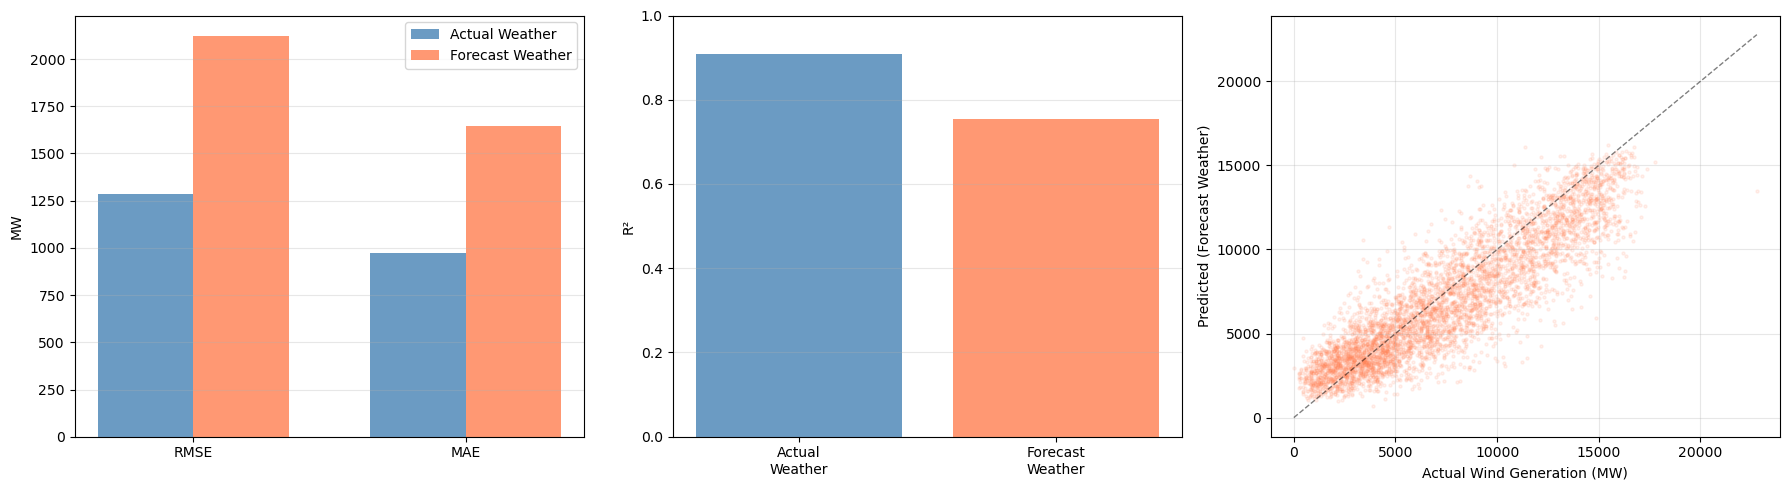

In [34]:
print("="*60)
print("FORECAST DEGRADATION ANALYSIS")
print("="*60)

if 'forecast_weather' in results:
    actual = results['actual_weather']
    forecast = results['forecast_weather']
    
    degradation_rmse = (forecast['rmse'] - actual['rmse']) / actual['rmse'] * 100
    degradation_mae = (forecast['mae'] - actual['mae']) / actual['mae'] * 100
    degradation_r2 = (actual['r2'] - forecast['r2']) / actual['r2'] * 100
    
    comparison = pd.DataFrame({
        'Metric': ['RMSE (MW)', 'MAE (MW)', 'R²'],
        'Actual Weather': [f"{actual['rmse']:.1f}", f"{actual['mae']:.1f}", f"{actual['r2']:.4f}"],
        'Forecast Weather': [f"{forecast['rmse']:.1f}", f"{forecast['mae']:.1f}", f"{forecast['r2']:.4f}"],
        'Degradation (%)': [f"{degradation_rmse:+.1f}%", f"{degradation_mae:+.1f}%", f"{degradation_r2:+.1f}%"],
    })
    
    print(comparison.to_string(index=False))
    
    print(f"\n→ Switching from actual to forecast weather increases RMSE by {degradation_rmse:.1f}%")
    print(f"  This quantifies the 'cost' of using leakage-free inputs.")
    print(f"  The trade-off is necessary for a realistic, deployable model.")
    
    # ─── Visualisation ───
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Bar chart comparison
    metrics_names = ['RMSE', 'MAE']
    actual_vals = [actual['rmse'], actual['mae']]
    forecast_vals = [forecast['rmse'], forecast['mae']]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    axes[0].bar(x - width/2, actual_vals, width, label='Actual Weather', color='steelblue', alpha=0.8)
    axes[0].bar(x + width/2, forecast_vals, width, label='Forecast Weather', color='coral', alpha=0.8)
    axes[0].set_ylabel('MW')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics_names)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # R² comparison
    axes[1].bar(['Actual\nWeather', 'Forecast\nWeather'],
                [actual['r2'], forecast['r2']],
                color=['steelblue', 'coral'], alpha=0.8)
    axes[1].set_ylabel('R²')
    axes[1].set_ylim(0, 1)
    axes[1].grid(axis='y', alpha=0.3)
    
    # Scatter: forecast weather predictions vs actual
    pred_fc_sample = pred_fc.sample(min(5000, len(pred_fc)), random_state=42)
    axes[2].scatter(pred_fc_sample['target_mw'], pred_fc_sample['predicted_mw'],
                    alpha=0.1, s=5, color='coral')
    max_val = max(pred_fc_sample['target_mw'].max(), pred_fc_sample['predicted_mw'].max())
    axes[2].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, lw=1)
    axes[2].set_xlabel('Actual Wind Generation (MW)')
    axes[2].set_ylabel('Predicted (Forecast Weather)')
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../figures/forecast_weather_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
else:
    print("⚠ Forecast weather results not available.")
    print("  Run 00_data_download.ipynb first to get weather forecast data,")
    print("  then re-run this section.")

# ### Key Findings
# 
# | Input Weather | RMSE (MW) | MAE (MW) | R² |
# |:---|:---|:---|:---|
# | **Actual weather** (original, has leakage) | 1286.2 | 975.6 | 0.9095 |
# | **Forecast weather** (leakage-free) | 2124.6 | 1648.0 | 0.7544 |
# | **Degradation** | 65.2%| 68.9% | 17.1% |
# 
# *Fill in after running the cells above.*
# 
# **Interpretation:** The degradation from actual → forecast weather quantifies how much predictive power comes from "knowing the future weather." In a realistic deployment:
# - Only forecast weather would be available at prediction time
# - The leakage-free model provides honest performance estimates
# - The comparison reveals the upper bound of improvement possible from better NWP models